In [9]:
import torch
from torchvision import datasets, transforms, models
import torch.nn as nn
import torch.optim as optim
import pathlib
from PIL import Image
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from torch.amp import autocast, GradScaler
import pandas as pd
import os

In [10]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
NUM_EPOCHS = 20
Dense_CHECKPOINT_PATH = "/kaggle/working/xray_bias_dense_model.pth"

In [11]:
from torch.utils.data import Dataset

class ChestXrayBiasDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        """
        Args:
            dataframe: The filtered dataframe (train_df, val_df, or test_df)
            image_dir: Path to the specific split folder (e.g., 'nih_split_data/train')
            transform: PyTorch transforms
        """
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Mapping 'Target' column to the actual subfolder names we created
        # Earlier we used 'Disease' and 'No Finding'
        subfolder = row['Target'] 
        img_path = os.path.join(self.image_dir, subfolder, row['Image Index'])

        # Load image as Grayscale 'L'
        image = Image.open(img_path).convert('L') 

        # Create Binary Label: 1 for Disease, 0 for No Finding
        binary_label = 1.0 if row['Target'] == 'Disease' else 0.0
        label = torch.tensor(binary_label).float()
        
        # Bias features (Protected attributes)
        gender = 1.0 if row['Patient Gender'] == 'F' else 0.0
        position = 1.0 if row['View Position'] == 'AP' else 0.0

        if self.transform:
            image = self.transform(image)

        return image, label, gender, position

In [76]:
# 1. Improved CSV loading and filtering
def create_split_df(base_path, sub_path, split_name):
    # Path to your balanced CSV
    csv_path = os.path.join(base_path, 'balanced_subsample.csv')
    master_df = pd.read_csv(csv_path)
    
    # Filter by the split (train, val, or test)
    split_df = master_df[master_df['Split'] == split_name].copy()
    
    # We check the specific subfolder for this split to verify files exist
    split_folder_path = os.path.join(base_path, sub_path, split_name)
    
    physical_files = []
    for subfolder in ['Disease', 'No Finding']:
        path = os.path.join(split_folder_path, subfolder)
        if os.path.exists(path):
            physical_files.extend(os.listdir(path))
            
    # Keep only rows where the image actually exists
    final_df = split_df[split_df['Image Index'].isin(physical_files)]
    return final_df.reset_index(drop=True)

# 2. Enhancement Function (Note: CLAHE requires grayscale for standard medical use)
def medical_enhancement(img):
    img_np = np.array(img)
    # If image is RGB, convert to LAB or YUV to apply CLAHE on luminance
    if len(img_np.shape) == 3:
        # Standard approach: apply to grayscale version or Luminance channel
        img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(img_np)
    return enhanced



# 3. Transforms
# If you want to use the medical_enhancement, you should add 
# transforms.Lambda(lambda x: medical_enhancement(x)) before ToTensor()
data_transform = {
    "train": transforms.Compose([
        transforms.Resize((224, 224)),
        # Add this line to turn [1, 224, 224] into [3, 224, 224]
        transforms.Grayscale(num_output_channels=1), 
        transforms.Lambda(lambda img: Image.fromarray(medical_enhancement(img))),
        transforms.Grayscale(num_output_channels=3), 
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    "val": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

# 4. Data Loading Setup
BATCH_SIZE = 32
main_path = '/kaggle/input/datasets/uyendang2404/nih-chest-balanced-split-v2'

# Corrected function calls
train_df = create_split_df(main_path,'sub_data', 'train')
val_df   = create_split_df(main_path, 'sub_data', 'val')
test_df  = create_split_df(main_path, 'sub_data', 'test')

# Ensure your ChestXrayBiasDataset class is defined to handle these dataframes
train_dataset = ChestXrayBiasDataset(train_df, os.path.join(main_path, 'sub_data/train'), data_transform['train'])
val_dataset   = ChestXrayBiasDataset(val_df,   os.path.join(main_path, 'sub_data/val'),   data_transform['val'])
test_dataset  = ChestXrayBiasDataset(test_df,  os.path.join(main_path, 'sub_data/test'),  data_transform['val'])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, num_workers=2)

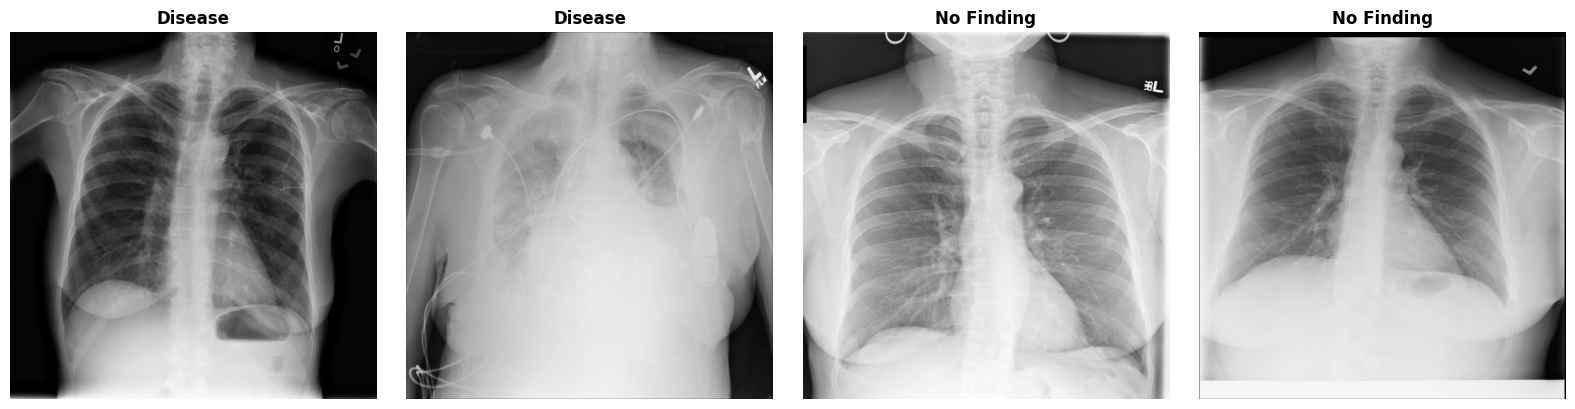

In [91]:
import os
import matplotlib.pyplot as plt
from PIL import Image

base_path = '/kaggle/input/datasets/uyendang2404/nih-chest-balanced-split-v2/sub_data/train/'

specific_files = [
    'Disease/00000005_006.png',
    'Disease/00000116_022.png',
    'No Finding/00000073_000.png',
    'No Finding/00000127_000.png'
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, file_path in enumerate(specific_files):
    full_path = os.path.join(base_path, file_path)
    
    if os.path.exists(full_path):
        # 1. Open the image
        img = Image.open(full_path)
        
        # 2. Plot the PIL image directly
        # Matplotlib handles PIL images natively
        axes[i].imshow(img, cmap='gray')
        
        # 3. Show the folder name (Disease or No Finding) as the title
        axes[i].set_title(file_path.split('/')[0], fontsize=12, fontweight='bold')
    else:
        axes[i].text(0.5, 0.5, 'File Not Found', ha='center', va='center')
        print(f"⚠️ Missing: {full_path}")
        
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('original_data.pdf')
plt.show()

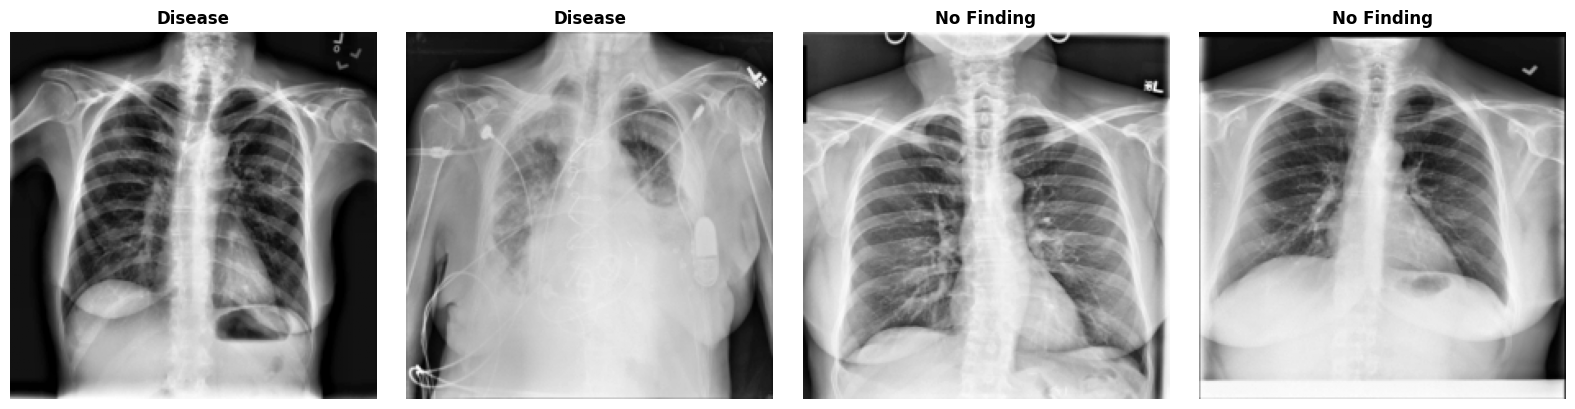

In [92]:
import os
import matplotlib.pyplot as plt
from PIL import Image

base_path = '/kaggle/input/datasets/uyendang2404/nih-chest-balanced-split-v2/sub_data/train/'

specific_files = [
    'Disease/00000005_006.png',
    'Disease/00000116_022.png',
    'No Finding/00000073_000.png',
    'No Finding/00000127_000.png'
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, file_path in enumerate(specific_files):
    full_path = os.path.join(base_path, file_path)
    
    if os.path.exists(full_path):
        # 1. Open the image
        img = Image.open(full_path)

        img_tensor = data_transform['train'](img)
        
        # Display the first channel as Grayscale
        img_display = img_tensor[0].numpy()
        
        # 2. Plot the PIL image directly
        # Matplotlib handles PIL images natively
        axes[i].imshow(img_display, cmap='gray')
        
        # 3. Show the folder name (Disease or No Finding) as the title
        axes[i].set_title(file_path.split('/')[0], fontsize=12, fontweight='bold')
    else:
        axes[i].text(0.5, 0.5, 'File Not Found', ha='center', va='center')
        print(f"⚠️ Missing: {full_path}")
        
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('preprocessed_data.pdf')
plt.show()